In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("Dataset_Clean.csv")
print(df.shape)
print(df.columns)
df.head()

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\AppData\Local\Temp\ipykernel_4372\410199134.py:3: DtypeWarning: Columns (0: label_text, 1: url, 2: speaker) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Dataset_Clean.csv")


(73726, 10)
Index(['id', 'title', 'content', 'label', 'label_text', 'label_original',
       'source_dataset', 'topic', 'url', 'speaker'],
      dtype='str')


,id,title,content,label,label_text,label_original,source_dataset,topic,url,speaker
0,LIAR_000000,Says the Annies List political group supports ...,Says the Annies List political group supports ...,1,Fake,false,LIAR,abortion,NaN,dwayne-bohac
1,LIAR_000001,When did the decline of coal start? It started...,When did the decline of coal start? It started...,3,Bias,half-true,LIAR,"energy,history,job-accomplishments",NaN,scott-surovell
2,LIAR_000002,"Hillary Clinton agrees with John McCain ""by vo...","Hillary Clinton agrees with John McCain ""by vo...",0,True,mostly-true,LIAR,foreign-policy,NaN,barack-obama
3,LIAR_000003,Health care reform legislation is likely to ma...,Health care reform legislation is likely to ma...,1,Fake,false,LIAR,health-care,NaN,blog-posting
4,LIAR_000004,The economic turnaround started at the end of ...,The economic turnaround started at the end of ...,3,Bias,half-true,LIAR,"economy,jobs",NaN,charlie-crist


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 73726 entries, 0 to 73725
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              73726 non-null  str   
 1   title           73726 non-null  str   
 2   content         73725 non-null  str   
 3   label           73726 non-null  int64 
 4   label_text      73726 non-null  object
 5   label_original  73726 non-null  str   
 6   source_dataset  73726 non-null  str   
 7   topic           51566 non-null  str   
 8   url             10523 non-null  str   
 9   speaker         23672 non-null  str   
dtypes: int64(1), object(1), str(8)
memory usage: 116.3+ MB


In [3]:
df.isnull().sum()

id                    0
title                 0
content               1
label                 0
label_text            0
label_original        0
source_dataset        0
topic             22160
url               63203
speaker           50054
dtype: int64

In [11]:
df['source_dataset'].value_counts()

source_dataset
ISOT                  38595
LIAR                  12765
MultiClass1            9611
TheOnion               6816
Propaganda             2799
NotTheOnion_Reddit     1573
Twitter                1058
India_MythFacts         219
BuzzFeed                178
PolitiFact_Scraped      111
Name: count, dtype: int64

Duplicate Rows: 0


In [6]:
print("Duplicate Content:", df['content'].duplicated().sum())

Duplicate Content: 0


In [7]:
df = df.dropna(subset=['content'])

In [8]:
df.isnull().sum()

id                    0
title                 0
content               0
label                 0
label_text            0
label_original        0
source_dataset        0
topic             22159
url               63202
speaker           50053
dtype: int64

In [9]:
df=df.drop(columns="url")

In [12]:
df['text'] = (
    df['title'].astype(str)
    + " "
    + df['content'].astype(str)
)

In [13]:
df['text'].head()

0    Says the Annies List political group supports ...
1    When did the decline of coal start? It started...
2    Hillary Clinton agrees with John McCain "by vo...
3    Health care reform legislation is likely to ma...
4    The economic turnaround started at the end of ...
Name: text, dtype: str

In [15]:
df['word_count'] = df['text'].apply(
    lambda x: len(str(x).split())
)

In [16]:
df['word_count'].describe()

count    73725.000000
mean       249.564503
std        289.832893
min          2.000000
25%         38.000000
50%        149.000000
75%        393.000000
max       5481.000000
Name: word_count, dtype: float64

In [17]:
df.drop(columns=['speaker'], inplace=True)

In [18]:
df['topic'] = df['topic'].fillna('unknown')

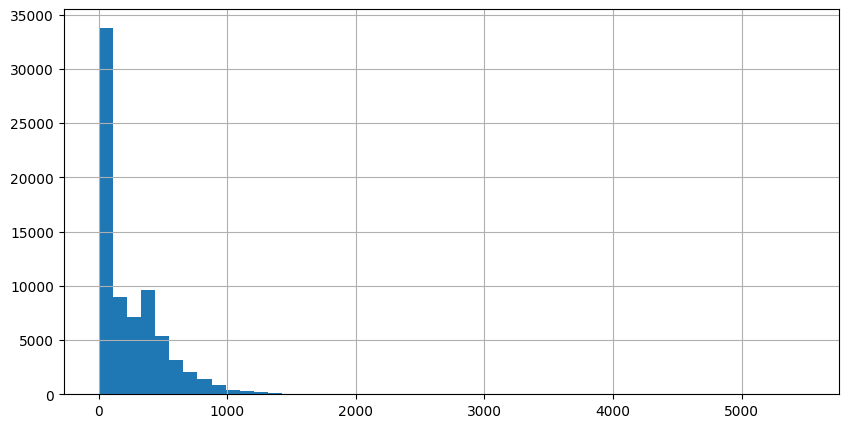

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df['word_count'].hist(
    bins=50
)

plt.show()

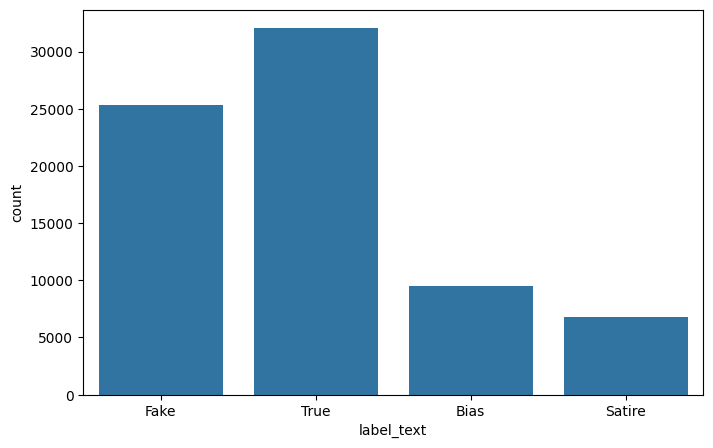

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='label_text',
    data=df,
    order=df['label_text'].value_counts().index
)

plt.show()

In [21]:
for i in range(5):
    print("="*100)
    print(df['text'].iloc[i][:1000])

Says the Annies List political group supports third-trimester abortions on demand. Says the Annies List political group supports third-trimester abortions on demand.
When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration. When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.
Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran." Hillary Clinton agrees with John McCain "by voting to give George Bush the benefit of the doubt on Iran."
Health care reform legislation is likely to mandate free sex change surgeries. Health care reform legislation is likely to mandate free sex change surgeries.
The economic turnaround started at the end of my term. The economic turnaround started at the end of my term.


In [22]:
print(df['label_text'].unique())

['Fake' 'Bias' 'True' 'Satire' True]


In [23]:
print(df['label_text'].value_counts(dropna=False))

label_text
Fake      25339
True      23879
Bias       9501
True       8190
Satire     6816
Name: count, dtype: int64


In [24]:
df['label_text'] = df['label_text'].astype(str)

In [25]:
print(df['label_text'].unique())

<ArrowStringArray>
['Fake', 'Bias', 'True', 'Satire']
Length: 4, dtype: str


In [26]:
print(df['label_text'].value_counts())

label_text
True      32069
Fake      25339
Bias       9501
Satire     6816
Name: count, dtype: int64


In [27]:
(
    df['title'].str.strip()
    ==
    df['content'].str.strip()
).mean()

np.float64(0.3529738894540522)

In [28]:
df['topic'].value_counts().head(20)

topic
unknown                 22159
politicsNews            11212
worldnews                9977
News                     9050
politics                 6365
US_News                   775
left-news                 680
Government News           514
health-care               474
taxes                     356
education                 308
elections                 304
immigration               302
candidates-biography      239
health/culture            219
economy                   169
federal-budget            152
guns                      152
economy,jobs              151
jobs                      121
Name: count, dtype: int64

In [29]:
df['text'] = (
    df['title'].fillna('')
    + ' '
    + df['content'].fillna('')
)

In [30]:
print(df[['text','label_text']].head())

                                                text label_text
0  Says the Annies List political group supports ...       Fake
1  When did the decline of coal start? It started...       Bias
2  Hillary Clinton agrees with John McCain "by vo...       True
3  Health care reform legislation is likely to ma...       Fake
4  The economic turnaround started at the end of ...       Bias


In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['target'] = le.fit_transform(df['label_text'])

print(le.classes_)
print(df[['label_text','target']].drop_duplicates().sort_values('target'))

['Bias' 'Fake' 'Satire' 'True']
      label_text  target
1           Bias       0
0           Fake       1
22665     Satire       2
2           True       3


In [32]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (58980,)
Test Shape : (14745,)


In [33]:
print("Train Distribution")
print(y_train.value_counts(normalize=True))

print("\nTest Distribution")
print(y_test.value_counts(normalize=True))

Train Distribution
target
3    0.434978
1    0.343693
0    0.128874
2    0.092455
Name: proportion, dtype: float64

Test Distribution
target
3    0.434995
1    0.343710
0    0.128857
2    0.092438
Name: proportion, dtype: float64


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF Shape:", X_train_tfidf.shape)
print("Test TF-IDF Shape :", X_test_tfidf.shape)

Train TF-IDF Shape: (58980, 50000)
Test TF-IDF Shape : (14745, 50000)


In [35]:
len(tfidf.get_feature_names_out())

50000

In [36]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['00' '00 pm' '000' '000 000' '000 americans' '000 and' '000 children'
 '000 emails' '000 employees' '000 euros' '000 fine' '000 for' '000 from'
 '000 in' '000 jobs' '000 more' '000 new' '000 of' '000 on' '000 or'
 '000 people' '000 per' '000 refugees' '000 residents' '000 rohingya'
 '000 square' '000 syrian' '000 the' '000 to' '000 tonnes' '000 troops'
 '000 votes' '000 year' '000 years' '038' '038 version' '10' '10 000'
 '10 2016' '10 2017' '10 and' '10 billion' '10 days' '10 in' '10 million'
 '10 minutes' '10 months' '10 of' '10 people' '10 percent']


In [37]:
print(X_train_tfidf.nnz)

13357087


In [38]:
print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

target
3    0.434978
1    0.343693
0    0.128874
2    0.092455
Name: proportion, dtype: float64

target
3    0.434995
1    0.343710
0    0.128857
2    0.092438
Name: proportion, dtype: float64


In [39]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

y_pred = lr_model.predict(
    X_test_tfidf
)

In [40]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

Accuracy: 0.8123431671753136
              precision    recall  f1-score   support

        Bias       0.44      0.89      0.59      1900
        Fake       0.92      0.79      0.85      5068
      Satire       0.96      0.99      0.97      1363
        True       0.96      0.77      0.85      6414

    accuracy                           0.81     14745
   macro avg       0.82      0.86      0.82     14745
weighted avg       0.88      0.81      0.83     14745



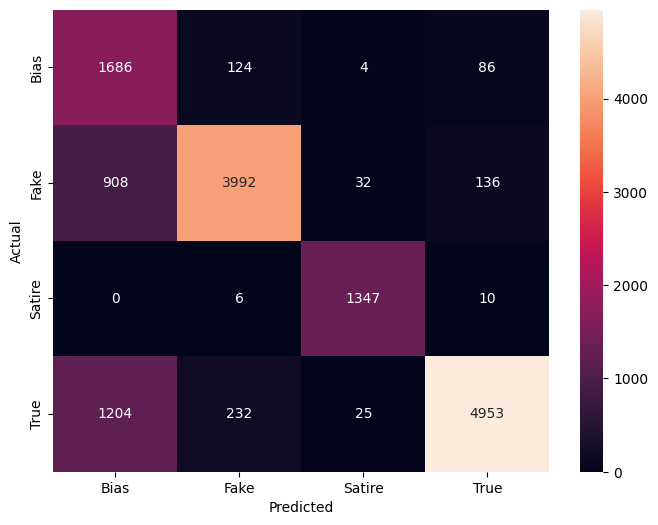

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'solver': ['lbfgs', 'saga']
}

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid.fit(
    X_train_tfidf,
    y_train
)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['lbfgs', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [43]:
print("Best Parameters:")
print(grid.best_params_)

print()

print("Best CV Score:")
print(grid.best_score_)

Best Parameters:
{'C': 10, 'class_weight': 'balanced', 'solver': 'saga'}

Best CV Score:
0.8253898875066268


In [44]:
best_lr = grid.best_estimator_

y_pred_tuned = best_lr.predict(
    X_test_tfidf
)

In [45]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_tuned
    )
)

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=le.classes_
    )
)

Accuracy: 0.8558155306883689
              precision    recall  f1-score   support

        Bias       0.57      0.75      0.65      1900
        Fake       0.89      0.86      0.87      5068
      Satire       0.97      0.98      0.98      1363
        True       0.92      0.86      0.89      6414

    accuracy                           0.86     14745
   macro avg       0.84      0.86      0.85     14745
weighted avg       0.87      0.86      0.86     14745



In [55]:
final_df = df[['text', 'label_text', 'target']]

final_df.to_csv(
    "fake_news_final.csv",
    index=False
)

print(final_df.shape)

(73725, 3)


In [56]:
import joblib

joblib.dump(best_lr, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Saved Successfully")

Saved Successfully


In [57]:
def predict_news(text):

    text_tfidf = tfidf.transform([text])

    pred = best_lr.predict(text_tfidf)[0]

    label = le.inverse_transform([pred])[0]

    return label

In [58]:
news = """
Scientists confirm Earth will be hit by a giant asteroid next week.
"""

print(predict_news(news))

Satire


In [59]:
import joblib

joblib.dump(best_lr, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("All files saved successfully!")

All files saved successfully!


In [60]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Dataset_Clean.csv', 'fake_news_final.csv', 'fake_news_model.pkl', 'label_encoder.pkl', 'tfidf_vectorizer.pkl', 'Untitled.ipynb']
